# Event Data Preprocessing

End-to-end pipeline for cleaning and feature-engineering raw e-commerce event data collected from the browser extension and stored in Supabase.

---

## 1. Setup

Import libraries, load environment variables, and initialise the Supabase client.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from supabase import create_client
from sklearn.preprocessing import MinMaxScaler
from dotenv import load_dotenv

load_dotenv()

supabase = create_client(
    os.environ["SUPABASE_URL"],
    os.environ["SUPABASE_KEY"]
)

## 2. Data Loading

Fetch all rows from the `events` table using pagination — Supabase caps each response at 1 000 rows, so we loop until the result set is exhausted.

In [2]:
# Supabase returns max 1000 rows per call — paginate to get all
def fetch_all(table):
    rows = []
    page = 0
    batch = 1000
    while True:
        res = supabase.table(table)\
                      .select("*")\
                      .range(page * batch, (page + 1) * batch - 1)\
                      .execute()
        if not res.data:
            break
        rows.extend(res.data)
        if len(res.data) < batch:
            break
        page += 1
    return pd.DataFrame(rows)

df = fetch_all("events")
print(f"Loaded {len(df)} rows, {df.shape[1]} columns")
df.head(3)

Loaded 198796 rows, 19 columns


,id,client_id,session_id,event_type,duration,logged_in,event_description,orders,order_description,timestamp,nb_visits,address,gender,age,pages_per_session,cart_abandonned,device,sequence,is_bounce
0,10b9fe83-9c75-4496-b235-2a74dafb4c0d,12505196.4752038393,9343342693,select_item,1949.0,True,"{'query': None, 'page_type': 'Men's / Unisex |...","[{'price': 69, 'coupon': '(not set)', 'item_id...","{'total': None, 'currency': None, 'categories'...",None,2,"Arizona, United States",None,NaN,7,False,desktop,"[page_view, session_start, scroll, page_view, ...",False
1,7e550dc4-4cd3-487e-b122-b355173a7000,13658081.6035203723,1782900701,view_item,3552.0,True,"{'query': None, 'page_type': 'YouTube | Shop b...","[{'price': 17, 'coupon': '(not set)', 'item_id...","{'total': None, 'currency': None, 'categories'...",None,1,"Minnesota, United States",None,NaN,2,False,desktop,"[session_start, page_view, first_visit, view_i...",False
2,7cd0ac97-15ab-4fee-913d-025bd613e562,16168766.5406439739,8410233959,view_item,9496.0,True,"{'query': None, 'page_type': 'Home', 'event_na...","[{'price': 40, 'coupon': '(not set)', 'item_id...","{'total': None, 'currency': None, 'categories'...",None,1,"Shanghai, China",None,NaN,2,False,desktop,"[first_visit, page_view, session_start, page_v...",False


## 3. Initial Exploration

Inspect raw shape, column data types, and the distribution of missing values to understand what cleaning is needed.

In [3]:
print("=== Shape ===")
print(df.shape)

print("\n=== Dtypes ===")
print(df.dtypes)

print("\n=== Null counts ===")
null_df = pd.DataFrame({
    "nulls": df.isnull().sum(),
    "pct":   (df.isnull().sum() / len(df) * 100).round(1)
})
print(null_df[null_df["nulls"] > 0].sort_values("pct", ascending=False))

=== Shape ===
(198796, 19)

=== Dtypes ===
id                    object
client_id             object
session_id            object
event_type            object
duration             float64
logged_in               bool
event_description     object
orders                object
order_description     object
timestamp             object
nb_visits              int64
address               object
gender                object
age                  float64
pages_per_session     object
cart_abandonned         bool
device                object
sequence              object
is_bounce             object
dtype: object

=== Null counts ===
                    nulls   pct
duration           146232  73.6
orders             105671  53.2
timestamp          103701  52.2
gender             102433  51.5
age                102433  51.5
order_description   87600  44.1
address             24758  12.5
pages_per_session   21715  10.9
is_bounce            2547   1.3
device               1533   0.8
event_type         

## 4. Flatten Nested Columns

`event_description` and `pages_per_session` arrive as JSON dicts. We expand each into flat columns prefixed with `ed_` and `pps_` respectively, then preview the result.

In [5]:
def safe_flatten(df, col, prefix):
    expanded = df[col].apply(lambda x: x if isinstance(x, dict) else {})
    flat = pd.json_normalize(expanded)
    flat.columns = [f"{prefix}_{c}" for c in flat.columns]
    return pd.concat([df.drop(columns=[col]), flat], axis=1)

In [6]:
if df["event_description"].dtype == object:
    df = safe_flatten(df, "event_description", "ed")

if "pages_per_session" in df.columns and df["pages_per_session"].dtype == object:
    df = safe_flatten(df, "pages_per_session", "pps")
print(df.columns.tolist())

['id', 'client_id', 'session_id', 'event_type', 'duration', 'logged_in', 'orders', 'order_description', 'timestamp', 'nb_visits', 'address', 'gender', 'age', 'cart_abandonned', 'device', 'sequence', 'is_bounce', 'ed_query', 'ed_page_type', 'ed_event_name', 'ed_funnel_stage', 'ed_action_source', 'ed_action_location', 'ed_action_label', 'ed_event_category', 'ed_price', 'ed_quantity', 'ed_depth_pct', 'ed_product_id', 'ed_click_count', 'ed_product_name', 'ed_max_scroll_pct', 'pps_page_views.page_views', 'pps_page_views']


In [7]:
df.head()

,id,client_id,session_id,event_type,duration,logged_in,orders,order_description,timestamp,nb_visits,...,ed_event_category,ed_price,ed_quantity,ed_depth_pct,ed_product_id,ed_click_count,ed_product_name,ed_max_scroll_pct,pps_page_views.page_views,pps_page_views
0,10b9fe83-9c75-4496-b235-2a74dafb4c0d,12505196.4752038393,9343342693,select_item,1949.0,True,"[{'price': 69, 'coupon': '(not set)', 'item_id...","{'total': None, 'currency': None, 'categories'...",None,2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,7e550dc4-4cd3-487e-b122-b355173a7000,13658081.6035203723,1782900701,view_item,3552.0,True,"[{'price': 17, 'coupon': '(not set)', 'item_id...","{'total': None, 'currency': None, 'categories'...",None,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,7cd0ac97-15ab-4fee-913d-025bd613e562,16168766.5406439739,8410233959,view_item,9496.0,True,"[{'price': 40, 'coupon': '(not set)', 'item_id...","{'total': None, 'currency': None, 'categories'...",None,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,6945842b-ebb7-4539-ac45-a27f493e9a4f,17106785.1789794982,9438572298,view_item,6665.0,True,"[{'price': 17, 'coupon': '(not set)', 'item_id...","{'total': None, 'currency': None, 'categories'...",None,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,56307859-8c2e-4a91-b500-8e1eff143c54,1143832.7767858698,7240508478,page_view,NaN,False,None,"{'total': None, 'currency': None, 'categories'...",None,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 5. Type Casting

Parse `timestamp` to UTC-aware datetime, coerce numeric fields, and normalise boolean flags so every column has the correct dtype before any analysis.

In [8]:
df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce", utc=True)
df["hour_of_day"]  = df["timestamp"].dt.hour
df["day_of_week"]  = df["timestamp"].dt.dayofweek
df["is_weekend"]   = df["day_of_week"].isin([5, 6]).astype(int)
for col in ["duration", "nb_visits", "age", "orders", "revenue"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

for col in ["ed_price", "ed_quantity", "ed_max_scroll_pct", "ed_click_count", "pps_page_views"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")
for col in ["logged_in", "cart_abandoned", "is_bounce"]:
    if col in df.columns:
        df[col] = df[col].map({True: True, False: False, "true": True,
                                "false": False, 1: True, 0: False})\
                         .fillna(False).astype(bool)
print("Types OK")
df.dtypes

Types OK


C:\Users\eya-pc\AppData\Local\Temp\ipykernel_19684\3255828940.py:16: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(False).astype(bool)


id                                        object
client_id                                 object
session_id                                object
event_type                                object
duration                                 float64
logged_in                                   bool
orders                                   float64
order_description                         object
timestamp                    datetime64[ns, UTC]
nb_visits                                  int64
address                                   object
gender                                    object
age                                      float64
cart_abandonned                             bool
device                                    object
sequence                                  object
is_bounce                                   bool
ed_query                                  object
ed_page_type                              object
ed_event_name                             object
ed_funnel_stage     

## 6. Column Summary

Build a per-column audit table showing dtype, null rate, unique-value count, and representative samples — a quick reference before deciding what to drop or impute.

In [10]:
def safe_nunique(series):
    try:
        return series.nunique(dropna=False)
    except TypeError:
        return series.astype(str).nunique(dropna=False)

def safe_sample(series, n=3):
    try:
        vals = series.dropna().iloc[:n].tolist()
        # convert any unhashable containers to repr strings
        return [str(v) if isinstance(v, (dict, list)) else v for v in vals]
    except Exception:
        return series.dropna().astype(str).iloc[:n].tolist()

summary_rows = []
for col in df.columns:
    n_null   = df[col].isna().sum()
    pct_null = n_null / len(df) * 100
    n_unique = safe_nunique(df[col])
    sample   = safe_sample(df[col]) if n_null < len(df) else ["ALL NULL"]
    summary_rows.append({
        "column":   col,
        "dtype":    str(df[col].dtype),
        "nulls":    n_null,
        "null_%":   round(pct_null, 1),
        "unique":   n_unique,
        "sample":   sample,
    })

col_summary = pd.DataFrame(summary_rows).set_index("column")
pd.set_option("display.max_colwidth", 80)
col_summary


,dtype,nulls,null_%,unique,sample
column,,,,,
id,object,0,0.0,127790,"[10b9fe83-9c75-4496-b235-2a74dafb4c0d, 7e550dc4-4cd3-487e-b122-b355173a7000,..."
client_id,object,0,0.0,57354,"[12505196.4752038393, 13658081.6035203723, 16168766.5406439739]"
session_id,object,0,0.0,66457,"[9343342693, 1782900701, 8410233959]"
event_type,object,3,0.0,35,"[select_item, view_item, view_item]"
duration,float64,146232,73.6,10921,"[1949.0, 3552.0, 9496.0]"
logged_in,bool,0,0.0,2,"[True, True, True]"
orders,float64,120823,60.8,5,"[0.0, 0.0, 0.0]"
order_description,object,87600,44.1,3249,"[{'total': None, 'currency': None, 'categories': [""Home/Apparel/Men's / Unis..."
timestamp,"datetime64[ns, UTC]",186283,93.7,5854,"[2026-04-30 06:50:42+00:00, 2026-04-30 06:50:42+00:00, 2026-04-30 18:39:42+0..."


## 7. Exploratory Data Analysis

Examine value distributions across categorical, boolean, and numeric columns to surface anomalies, high-cardinality fields, and skewed distributions.

In [11]:
cat_cols  = df.select_dtypes(include="object").columns.tolist()
bool_cols = df.select_dtypes(include="bool").columns.tolist()

print("=== Categorical columns ===")
for col in cat_cols:
    try:
        vc = df[col].value_counts(dropna=False).head(10)
        n_unique = df[col].nunique()
    except TypeError:
        vc = df[col].astype(str).value_counts(dropna=False).head(10)
        n_unique = df[col].astype(str).nunique()
    print(f"\n── {col}  (unique={n_unique}, nulls={df[col].isna().sum():,})")
    print(vc.to_string())

print("\n=== Boolean columns ===")
for col in bool_cols:
    vc = df[col].value_counts(dropna=False)
    pct_true = df[col].sum() / len(df) * 100
    print(f"\n── {col}  (True: {pct_true:.1f}%)")


=== Categorical columns ===

── id  (unique=127790, nulls=0)
id
e9ee8dc0-2cf1-4bdd-8d06-835b6ee3e47c    4
e8424f6a-cdff-4da3-8cfa-297e0f6e5de9    4
f86c5f7f-cd4e-4f1a-bddf-266933e9ccd6    4
60458dff-d1a8-4142-bf9c-6be6a48c59da    4
c49aac6d-d366-459c-82a3-f37d5cd87af0    4
dcc3cb46-6a06-4de4-bbf0-3c3b071cf2e3    4
5e7cbd82-c42b-4d5e-91e5-6385522ca02a    4
02cd7180-60e9-4481-ac76-591b7690254e    4
3324e3b4-72ca-4652-8b8d-60d5b93a060f    4
8b11544b-a73a-45ac-9132-6c1727fec30b    4

── client_id  (unique=57354, nulls=0)
client_id
anon_fce3cb3f-6702-4a02-ab1c-a7094e44e940    255
anon_73253982-df0a-4c54-89ee-bdebcf209175    238
anon_f012c05c-8415-449f-b3e9-e4112e99fd41    219
anon_e1cf63f7-ec5b-43d9-b980-ff2aeb97708a    209
anon_e033c7e8-6d99-4742-8c88-a1c8e679461a    194
anon_b2e66a2a-ed41-4dea-9287-df11cda05f3d    192
anon_e5edf383-3e93-408a-af02-8b7cbdd332b4    186
anon_fdab9200-a110-4f47-ada9-e391463650c9    183
anon_6477a567-6c6c-4011-ac27-e7363abc52d2    181
anon_fcae01da-61ad-4879-90

### 7.1 Missingness Overview

Visualise null rates per column and a row-level missingness matrix to identify patterns (e.g. columns that are always null together).

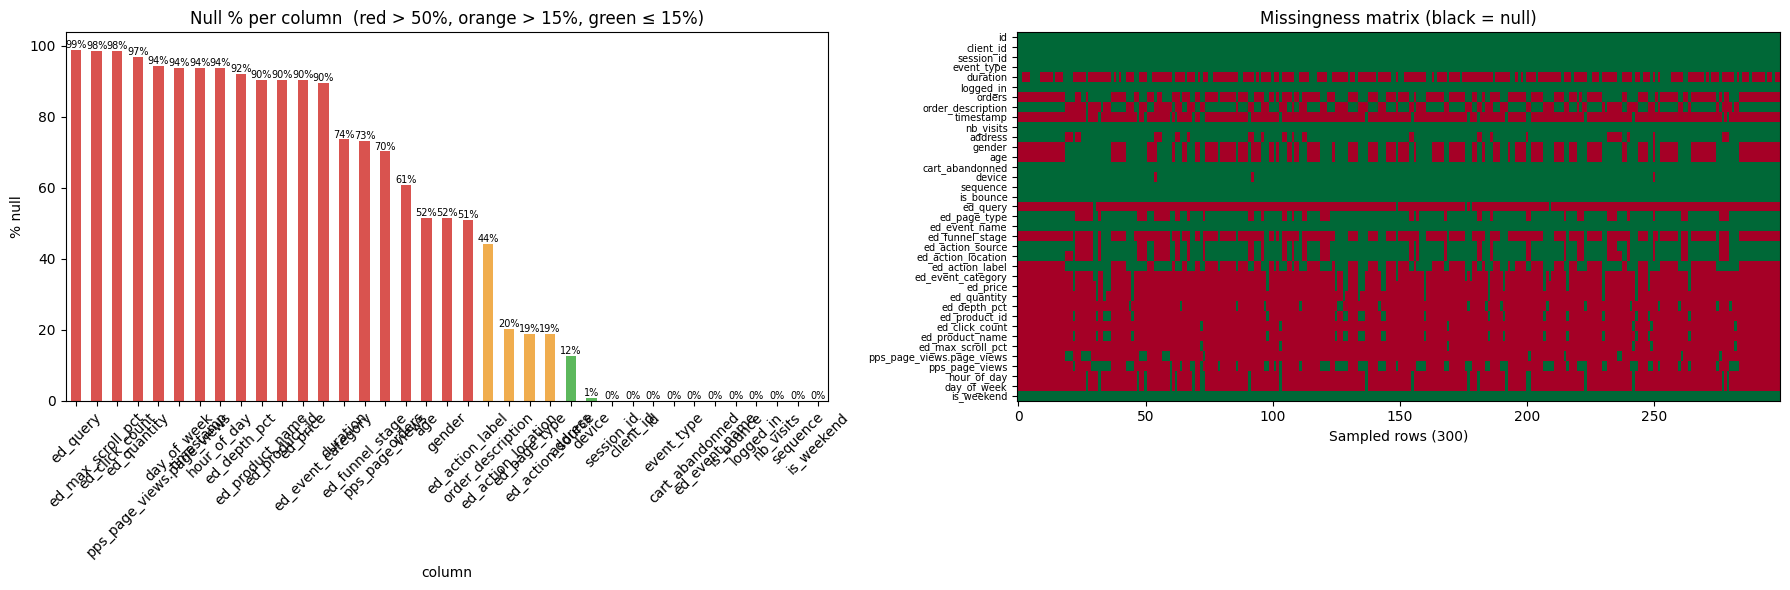

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

null_pct = col_summary["null_%"].sort_values(ascending=False)
colors = ["#d9534f" if v > 50 else "#f0ad4e" if v > 15 else "#5cb85c" for v in null_pct]
null_pct.plot(kind="bar", ax=axes[0], color=colors)
axes[0].set_title("Null % per column  (red > 50%, orange > 15%, green ≤ 15%)")
axes[0].set_ylabel("% null")
axes[0].tick_params(axis="x", rotation=45)
for i, v in enumerate(null_pct):
    axes[0].text(i, v + 0.5, f"{v:.0f}%", ha="center", fontsize=7)
# Right: missingness matrix (sample of rows)
import random
sample_idx = sorted(random.sample(range(len(df)), min(300, len(df))))
miss_matrix = df.iloc[sample_idx].isna().astype(int)
axes[1].imshow(miss_matrix.T, aspect="auto", cmap="RdYlGn_r", interpolation="none")
axes[1].set_yticks(range(len(df.columns)))
axes[1].set_yticklabels(df.columns, fontsize=7)
axes[1].set_xlabel("Sampled rows (300)")
axes[1].set_title("Missingness matrix (black = null)")

plt.tight_layout()
plt.savefig("null_overview.png", dpi=150)
plt.show()


### 7.2 Numeric Distributions

Plot histograms for all numeric columns to detect skew, outliers, and zero-inflation before imputation.

=== Numeric describe ===


,count,mean,std,min,25%,50%,75%,max
duration,52564.0,6459.30,28139.12,0.0,20.00,252.00,5845.00,1698532.00
orders,77973.0,0.03,0.17,0.0,0.00,0.00,0.00,3.00
nb_visits,198796.0,2.39,4.40,1.0,1.00,1.00,2.00,153.00
age,96363.0,31.80,20.54,0.0,21.00,34.00,46.00,72.00
ed_price,19016.0,117.62,123.71,5.0,28.49,70.59,163.56,774.89
ed_quantity,6173.0,1.67,0.76,1.0,1.00,1.00,2.00,3.00
ed_depth_pct,15888.0,58.68,22.19,10.0,42.00,60.00,76.00,100.00
ed_click_count,3072.0,13.15,9.83,0.0,4.00,13.00,22.00,30.00
ed_max_scroll_pct,3072.0,53.83,25.79,0.0,35.00,57.00,74.00,100.00
pps_page_views.page_views,11334.0,11.93,8.21,1.0,5.00,11.00,17.00,46.00


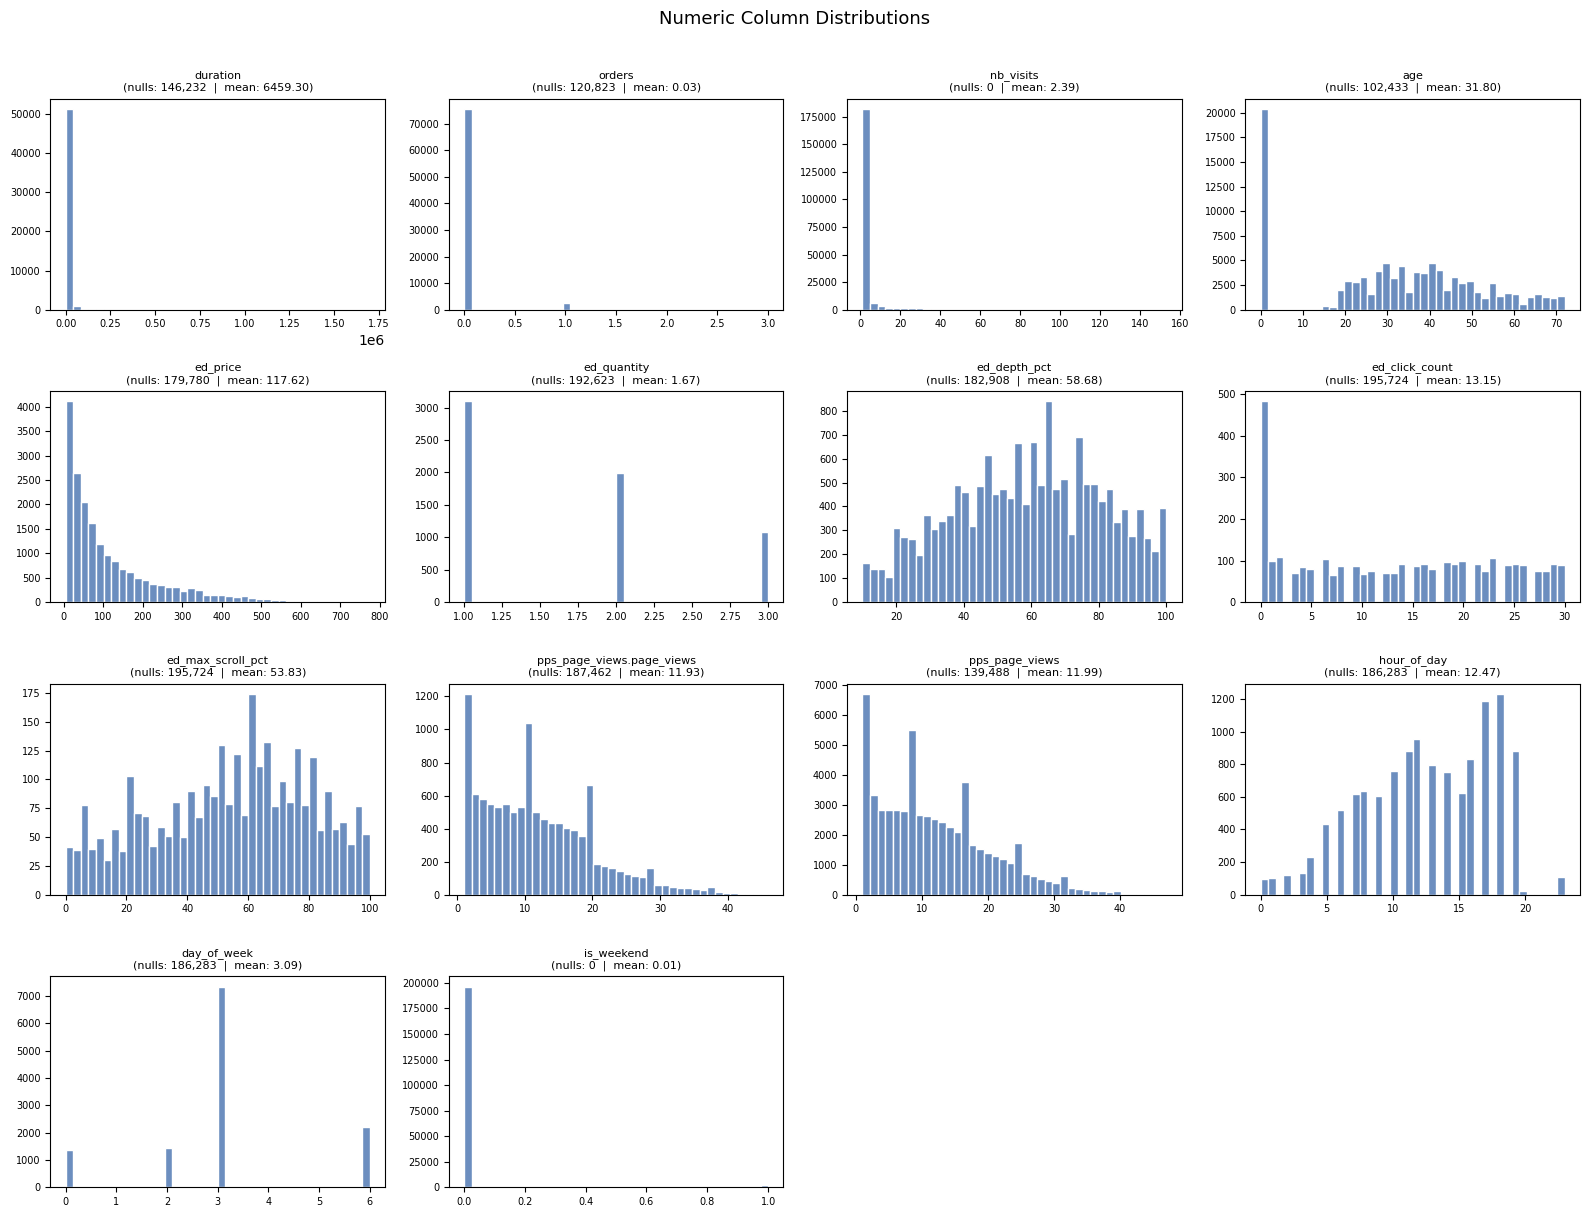

In [13]:
num_cols = df.select_dtypes(include="number").columns.tolist()
print("=== Numeric describe ===")
display(df[num_cols].describe().T.round(2))

n = len(num_cols)
cols_per_row = 4
rows_needed  = (n + cols_per_row - 1) // cols_per_row
fig, axes = plt.subplots(rows_needed, cols_per_row, figsize=(16, rows_needed * 3))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    data = df[col].dropna()
    axes[i].hist(data, bins=40, color="#6C8EBF", edgecolor="white")
    axes[i].set_title(f"{col}\n(nulls: {df[col].isna().sum():,}  |  mean: {data.mean():.2f})", fontsize=8)
    axes[i].tick_params(labelsize=7)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Numeric Column Distributions", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("numeric_distributions.png", dpi=150, bbox_inches="tight")
plt.show()


## 8. Column Cleanup

Drop columns that are redundant (exact duplicates), near-empty (> 95 % null with no predictive value), or obfuscated (`ed_query`).

In [14]:
# pps_page_views.page_views is a duplicate of pps_page_views — drop it
df = df.drop(columns=["pps_page_views.page_views"], errors="ignore")

# ed_event_name is identical to event_type — drop it
df = df.drop(columns=["ed_event_name"], errors="ignore")

# ed_query is 98.8% null and mostly obfuscated — not useful
df = df.drop(columns=["ed_query"], errors="ignore")

# ed_product_id and ed_product_name are 89.8% null — keep but don't impute
# ed_event_category is 88.9% null — keep for context agent later

print("Columns after drop:", df.shape[1])

Columns after drop: 34


## 9. Imputation & Cleaning

Fill missing values using per-client aggregations (mode for categoricals, median for `age`), standardise free-text `device` strings, and propagate sparse labels such as `ed_funnel_stage` within each client.

In [15]:
df["session_id"] = df["session_id"].fillna(
    "sess_" + df["client_id"].astype(str) + "_" + df.index.astype(str)
)
# ── gender: standardize all noise to NaN ─────────────────────
df["gender"] = df.groupby("client_id")["gender"].transform(
    lambda x: x.mode()[0] if not x.mode().empty else pd.NA
)
df["gender"] = df["gender"].fillna("unknown")
df["age"] = df["age"].replace(0, pd.NA)
df["age"] = df.groupby("address")["age"].transform(
    lambda x: x.fillna(x.median())
)
df["age"] = df["age"].fillna(df["age"].median())

df["device"] = df["device"].str.split("|").str[0].str.strip().str.lower()
df["device"] = df["device"].replace({"unknown": pd.NA, "": pd.NA})
df["device"] = df["device"].where(df["device"].isin(["mobile", "desktop", "tablet"]), "other")
df["device"] = df["device"].fillna(
    df.groupby("client_id")["device"].transform(
        lambda x: x.mode()[0] if not x.mode().empty else "mobile"
    )
)
df["address"] = df.groupby("client_id")["address"].transform(
    lambda x: x.mode()[0] if not x.mode().empty else "unknown"
)
df["ed_event_category"] = df.groupby("client_id")["ed_event_category"].transform(
    lambda x: x.mode()[0] if not x.mode().empty else "unknown"
)
df["ed_action_label"] = df["ed_action_label"].fillna("none")
df["ed_funnel_stage"] = df.groupby("client_id")["ed_funnel_stage"].transform(
    lambda x: x.ffill().bfill()
)
df["ed_funnel_stage"] = df["ed_funnel_stage"].fillna("awareness")
df["ed_event_category"] = df["ed_event_category"].replace("NaN", pd.NA)

print("Dirty values cleaned ✓")
print(df["gender"].value_counts(dropna=False))
print(df["device"].value_counts(dropna=False))

c:\backup\Bureau\Eya\data mining\.venv\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1213: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
C:\Users\eya-pc\AppData\Local\Temp\ipykernel_19684\1523929006.py:11: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  lambda x: x.fillna(x.median())
c:\backup\Bureau\Eya\data mining\.venv\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1213: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
C:\Users\eya-pc\AppData\Local\Temp\ipykernel_19684\1523929006.py:11: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the 

Dirty values cleaned ✓
gender
unknown    121568
F           37674
M           34767
other        4787
Name: count, dtype: int64
device
mobile     94738
desktop    85097
tablet     17123
other       1838
Name: count, dtype: int64


## 10. Basic Feature Engineering

Derive first-pass behavioural signals from raw event counts: loyalty score (total events per client), purchase-intent flag, engagement score, and session length.

In [16]:
df["loyalty_score"] = df.groupby("client_id")["event_type"].transform("count")
df["intent_score"] = df["event_type"].isin(
    ["product_view", "add_to_cart"]
).astype(int)
df["engagement_score"] = (
    (df["event_type"] == "user_engagement").astype(int) +
    (df["event_type"] == "scroll_depth").astype(int)
)
df["session_length"] = df.groupby("session_id")["event_type"].transform("count")

## 11. Timestamp Repair

Many events lack explicit timestamps. Sort events by client → timestamp, then propagate timestamps within each session via forward/backward fill; fall back to the global median for any remaining nulls.

In [17]:
df = df.sort_values(["client_id", "timestamp"])

df["timestamp"] = df.groupby("client_id")["timestamp"].ffill()

In [22]:
df.shape

(198796, 41)

In [23]:
df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce", utc=True)

In [24]:
df = df.sort_values(["session_id", "timestamp"])

df["timestamp"] = df.groupby("session_id")["timestamp"].ffill()
df["timestamp"] = df.groupby("session_id")["timestamp"].bfill()

In [25]:
df["timestamp"] = df.groupby("client_id")["timestamp"].transform(
    lambda x: x.ffill().bfill()
)

In [26]:
df["timestamp"] = df["timestamp"].fillna(df["timestamp"].median())

In [27]:
df["event_type"].value_counts()

event_type
page_view              46009
scroll_depth           27864
product_view           21115
session_start          18866
user_engagement        17731
first_visit            12668
view_promotion          9967
add_to_cart             8562
page_engagement         8156
scroll                  7387
view_item               4617
search_performed        3572
remove_from_cart        2045
checkout_started        1935
promo_viewed            1398
purchase_completed      1343
unknown                 1278
cart_abandon             907
product_viewed           844
                         557
view_search_results      365
select_promotion         360
select_item              311
checkout_abandon         300
session_ended            270
begin_checkout           172
cart_abandoned            47
add_shipping_info         39
add_payment_info          32
purchase                  29
click                     18
checkout_abandoned        13
view_item_list            10
review_submitted           6
Nam

In [29]:
df = df[df["event_type"].notna()]

## 13. Final Null Check & Fill

After structural cleaning, zero-fill sparse interaction metrics, impute remaining location fields by per-client mode, and verify no critical column is still null.

In [32]:
df = df.sort_values(["client_id", "session_id"])

df["timestamp"] = df.groupby("session_id")["timestamp"].transform(
    lambda x: x.ffill().bfill()
)

## 12. Event Type Cleanup

Inspect the `event_type` distribution and remove the three rows with a null event type — they carry no actionable signal.

In [34]:
print(df.isnull().sum()[df.isnull().sum() > 0].sort_values(ascending=False))

ed_max_scroll_pct     195721
ed_click_count        195721
ed_quantity           192620
day_of_week           186280
hour_of_day           186280
ed_depth_pct          182905
ed_product_name       179777
ed_product_id         179777
ed_price              179777
duration              146229
pps_page_views        139485
orders                120823
order_description      87597
ed_action_location     39994
ed_page_type           37447
ed_action_source       37447
sequence                   1
dtype: int64


In [35]:
df["ed_max_scroll_pct"] = df["ed_max_scroll_pct"].fillna(0)
df["ed_click_count"] = df["ed_click_count"].fillna(0)
df["ed_depth_pct"] = df["ed_depth_pct"].fillna(0)
df["duration"] = df["duration"].fillna(0)

In [36]:
df["ed_product_id"] = df["ed_product_id"].fillna("none")
df["ed_product_name"] = df["ed_product_name"].fillna("none")
df["orders"] = df["orders"].fillna(0)
df["pps_page_views"] = df["pps_page_views"].fillna(0)

In [37]:
df["has_order"] = df["orders"].notna().astype(int)

In [38]:
df["order_description"] = df["order_description"].fillna("{}")

In [39]:
for col in ["ed_action_location", "ed_page_type", "ed_action_source"]:
    
    mode_map = df.groupby("client_id")[col].agg(
        lambda x: x.dropna().mode().iloc[0] if not x.dropna().mode().empty else "unknown"
    )

    df[col] = df["client_id"].map(mode_map)

In [40]:
df["sequence"] = df["sequence"].fillna("[]")

## 14. Advanced Feature Engineering

Parse the raw `sequence` column into ordered step lists, then build higher-level signals: funnel depth, purchaser flag, deep-scroll and high-engagement indicators, and event recency in days.

In [ ]:
def parse_sequence(seq):
    if isinstance(seq, (list, np.ndarray)):
        return list(seq) if len(seq) > 0 else []
    try:
        if pd.isna(seq) or seq == "" or seq == "['']":
            return []
    except:
        return []

    if isinstance(seq, str):
        seq = seq.strip().strip("[]\"'")
        if "→" in seq:
            return [s.strip() for s in seq.split("→")]
        if "->" in seq:
            return [s.strip() for s in seq.split("->")]
        return [seq]

    return []

df["sequence_parsed"] = df["sequence"].apply(parse_sequence)
df["sequence_len"]    = df["sequence_parsed"].apply(len)
df["last_step"]       = df["sequence_parsed"].apply(
    lambda x: x[-1] if x else "unknown"
)
print(df["sequence_parsed"].head(5))
print(df["last_step"].value_counts().head(10))

In [42]:
from datetime import timezone

NOW = pd.Timestamp.now(tz="UTC")

# ── Funnel depth (you already have this, just confirm) ───────
FUNNEL_MAP = {
    "home":1,"search":2,"product_view":3,"add_to_cart":4,
    "cart_view":5,"checkout":6,"checkout_abandon":5,
    "purchase":7,"bounce":0
}
df["funnel_depth"] = df["sequence_parsed"].apply(
    lambda steps: max((FUNNEL_MAP.get(s,0) for s in steps), default=0)
)

# ── Session-level signals ────────────────────────────────────
df["is_purchaser"]     = (df["orders"] > 0).astype(int)
df["reached_checkout"] = df["funnel_depth"].ge(6).astype(int)
df["deep_scroll"]      = df["ed_max_scroll_pct"].ge(70).astype(int)
df["high_engagement"]  = (
    (df["ed_click_count"] >= 5) & (df["ed_max_scroll_pct"] >= 50)
).astype(int)

# ── Time signals ─────────────────────────────────────────────
df["recency_days_event"] = (NOW - df["timestamp"]).dt.days


print("Event-level columns added ✓")
print(df[["funnel_depth","is_purchaser","deep_scroll","high_engagement"]].describe())

Event-level columns added ✓
        funnel_depth   is_purchaser    deep_scroll  high_engagement
count  198793.000000  198793.000000  198793.000000    198793.000000
mean        0.703345       0.011836       0.004744         0.008013
std         1.521996       0.108150       0.068711         0.089158
min         0.000000       0.000000       0.000000         0.000000
25%         0.000000       0.000000       0.000000         0.000000
50%         0.000000       0.000000       0.000000         0.000000
75%         0.000000       0.000000       0.000000         0.000000
max         7.000000       1.000000       1.000000         1.000000


## 15. Export

Save the fully preprocessed dataset to CSV for use in downstream modelling pipelines.

In [45]:
df.to_csv("events_cleaned.csv", index=False)